#### EDA-Feature Engineering pipeline
Для меня самое главное - понять как гипотезы появляются в процессе:

"Раскопки данных" -> Построение гипотез  по тому как устроены данные и репрезентативных графиков в доказательство своих мылсей о данных -> Осмысленные выводы и гипотезы/предложения по созданию features ->  обучение BL моделей с feature engineering и без для сравнения полученного эффекта

# 1. Первичный анализ данных

На этом этапе выполняется первичный осмотр датасета без построения гипотез и без анализа зависимостей между признаками и стоимостью дома.

Задачи этапа:

- определить размер датасета;
- проверить строки и столбцы;
- определить целевую переменную;
- посмотреть распределение целевой переменной;
- изучить типы и смысл признаков;
- проверить количество уникальных значений;
- найти технические пропуски;
- отделить пропуски от значений, означающих отсутствие объекта;
- проверить дубликаты и базовую согласованность данных.

## 1. Импорты и загрузка данных

In [38]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


from IPython.display import display


DATA_PATH = Path("data_raw/train.csv")
DESCRIPTION_PATH = Path("data_raw/data_description.txt")

TARGET = "SalePrice"
ID_COLUMN = "Id"

### Особенность загрузки данных

В исходном CSV используются строковые значения:

- `NA` — иногда отсутствие объекта, например отсутствие гаража или бассейна или ПРОПУСК;
- `None` — полноценная допустимая категория признака `MasVnrType`, означающая отсутствие каменной облицовки. .
- `NaN` - пропущенное значение в Pandas.

Стандартный вызов `pd.read_csv()` может автоматически преобразовать и `NA`, и `None` в `NaN`.

Поэтому сначала загрузим файл без автоматического распознавания пропусков, а затем отдельно преобразуем необходимые числовые столбцы.

In [39]:
# raw_df сохраняет исходные значения CSV без автоматической
# замены строк "NA" и "None" на NaN.
raw_df = pd.read_csv(
    DATA_PATH,
    keep_default_na=False,
)

df = raw_df.copy()


# В этих числовых столбцах строка "NA" должна быть преобразована в NaN.
numeric_columns_with_na = [
    "LotFrontage",
    "MasVnrArea",
    "GarageYrBlt",
]

for column in numeric_columns_with_na:
    df[column] = pd.to_numeric(
        df[column],
        errors="coerce", # Если значение нельзя преобразовать в число, оно заменяется на NaN.
    )


# В Electrical есть одна строка "NA".
# В отличие от признаков вроде GarageType, здесь "NA"
# не является отдельной категорией из data_description.
df["Electrical"] = df["Electrical"].replace(
    "NA",
    pd.NA,
)

## 2. Общая информация о датасете

In [40]:
dataset_overview = pd.Series(
    {
        "Количество строк": df.shape[0],
        "Количество столбцов": df.shape[1],
        "Количество признаков без Id": (
            df.shape[1] - 2
        ),
        "Количество числовых столбцов": (
            df.select_dtypes(include=np.number).shape[1]
        ),
        "Количество object-столбцов": (
            df.select_dtypes(include="object").shape[1]
        ),
        "Количество дубликатов строк": (
            df.duplicated().sum()
        ),
        "Количество уникальных Id": (
            df[ID_COLUMN].nunique()
        ),
        "Количество пропусков в таргете": (
            df[TARGET].isna().sum()
        ),
    },
    name="value",
)

display(dataset_overview.to_frame())

,value
Количество строк,1460
Количество столбцов,81
Количество признаков без Id,79
Количество числовых столбцов,38
Количество object-столбцов,43
Количество дубликатов строк,0
Количество уникальных Id,1460
Количество пропусков в таргете,0


### Общая структура датасета

В датасете находится 1460 наблюдений и 81 столбец:

- `Id` — идентификатор объекта;
- 79 признаков, описывающих дом, участок и условия продажи;
- `SalePrice` — целевая переменная.

Все 1460 значений `Id` уникальны.

Полных дубликатов строк нет.

В целевой переменной `SalePrice` пропусков нет.

## 3. Просмотр строк датасета

In [41]:
display(df.head())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,12,2008,WD,Normal,250000


In [42]:
display(df.tail())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
1455,1456,60,RL,62.0,7917,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NA,Reg,Lvl,AllPub,...,0,NA,MnPrv,NA,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NA,Reg,Lvl,AllPub,...,0,NA,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,4,2010,WD,Normal,142125
1459,1460,20,RL,75.0,9937,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,6,2008,WD,Normal,147500


In [43]:
display(
    df.sample(
        n=5,
        random_state=42,
    )
)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
892,893,20,RL,70.0,8414,Pave,NA,Reg,Lvl,AllPub,...,0,NA,MnPrv,NA,0,2,2006,WD,Normal,154500
1105,1106,60,RL,98.0,12256,Pave,NA,IR1,Lvl,AllPub,...,0,NA,NA,NA,0,4,2010,WD,Normal,325000
413,414,30,RM,56.0,8960,Pave,Grvl,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,3,2010,WD,Normal,115000
522,523,50,RM,50.0,5000,Pave,NA,Reg,Lvl,AllPub,...,0,NA,NA,NA,0,10,2006,WD,Normal,159000
1036,1037,20,RL,89.0,12898,Pave,NA,IR1,HLS,AllPub,...,0,NA,NA,NA,0,9,2009,WD,Normal,315500


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          1460 non-null   object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

### Типы данных

После контролируемой загрузки:

- 43 столбца имеют тип `object`;
- 35 столбцов имеют тип `int64`;
- 3 столбца имеют тип `float64`.

Тип pandas не всегда совпадает с фактической природой признака.

Например:

- `MSSubClass` хранится как число, но числа являются кодами типов домов;
- `OverallQual` и `OverallCond` являются порядковыми оценками от 1 до 10;
- `MoSold` является номером месяца;
- `YrSold`, `YearBuilt`, `YearRemodAdd` и `GarageYrBlt` являются временными признаками;
- `Id` является идентификатором, а не характеристикой дома.

## 4. Каталог всех признаков - собирает всю основную информацию о каждом столбце в одной таблице (справочник по датасету).

Для каждого признака мы одновременно видим:
- как называется столбец;
- что он означает;
- какой у него тип данных;
- сколько в нём уникальных значений;
- сколько пропусков;
- какие значения реально встречаются;
- является ли он признаком, идентификатором или таргетом.

Названия признаков сокращённые, и по ним не всегда понятно содержание:

Следующая ячейка извлекает краткие описания непосредственно из data_description.txt.
В текстовом описании используются названия Bedroom и Kitchen, тогда как в CSV соответствующие столбцы называются BedroomAbvGr и KitchenAbvGr.

In [45]:
description_text = DESCRIPTION_PATH.read_text(
    encoding="utf-8",
)

description_records = []

for line in description_text.splitlines():
    # Названия признаков находятся в строках без отступа
    # и отделяются от описания двоеточием.
    if (
        line
        and not line[0].isspace()
        and ":" in line
    ):
        feature, description = line.split(
            ":",
            maxsplit=1,
        )

        description_records.append(
            {
                "feature": feature.strip(),
                "description": description.strip(),
            }
        )


description_df = pd.DataFrame(
    description_records
)


# Названия в data_description.txt отличаются
# от названий столбцов в CSV.
description_df["feature"] = (
    description_df["feature"].replace(
        {
            "Bedroom": "BedroomAbvGr",
            "Kitchen": "KitchenAbvGr",
        }
    )
)


additional_descriptions = pd.DataFrame(
    [
        {
            "feature": "Id",
            "description": (
                "Unique identifier of the property."
            ),
        },
        {
            "feature": "SalePrice",
            "description": (
                "Property sale price in dollars. "
                "Target variable."
            ),
        },
    ]
)

description_df = pd.concat(
    [
        additional_descriptions,
        description_df,
    ],
    ignore_index=True,
)

In [46]:
def get_example_values(
    series: pd.Series,
    n_values: int = 5,
) -> list:
    """
    Возвращает несколько примеров значений столбца.
    """
    return (
        series
        .dropna()
        .astype(str)
        .drop_duplicates()
        .head(n_values)
        .tolist()
    )


feature_catalog = pd.DataFrame(
    {
        "feature": df.columns,
        "role": [
            (
                "identifier"
                if column == ID_COLUMN
                else "target"
                if column == TARGET
                else "feature"
            )
            for column in df.columns
        ],
        "dtype": df.dtypes.astype(str).values,
        "n_unique": [
            df[column].nunique(
                dropna=True
            )
            for column in df.columns
        ],
        "missing_count": [
            df[column].isna().sum()
            for column in df.columns
        ],
        "missing_pct": [
            df[column].isna().mean() * 100
            for column in df.columns
        ],
        "example_values": [
            get_example_values(
                df[column]
            )
            for column in df.columns
        ],
    }
)

feature_catalog = feature_catalog.merge(
    description_df,
    on="feature",
    how="left",
)

feature_catalog["missing_pct"] = (
    feature_catalog["missing_pct"].round(2)
)

pd.set_option(
    "display.max_colwidth",
    120,
)

display(feature_catalog)

,feature,role,dtype,n_unique,missing_count,missing_pct,example_values,description
0,Id,identifier,int64,1460,0,0.00,"[1, 2, 3, 4, 5]",Unique identifier of the property.
1,MSSubClass,feature,int64,15,0,0.00,"[60, 20, 70, 50, 190]",Identifies the type of dwelling involved in the sale.
2,MSZoning,feature,object,5,0,0.00,"[RL, RM, C (all), FV, RH]",Identifies the general zoning classification of the sale.
3,LotFrontage,feature,float64,110,259,17.74,"[65.0, 80.0, 68.0, 60.0, 84.0]",Linear feet of street connected to property
4,LotArea,feature,int64,1073,0,0.00,"[8450, 9600, 11250, 9550, 14260]",Lot size in square feet
...,...,...,...,...,...,...,...,...
76,MoSold,feature,int64,12,0,0.00,"[2, 5, 9, 12, 10]",Month Sold (MM)
77,YrSold,feature,int64,5,0,0.00,"[2008, 2007, 2006, 2009, 2010]",Year Sold (YYYY)
78,SaleType,feature,object,9,0,0.00,"[WD, New, COD, ConLD, ConLI]",Type of sale
79,SaleCondition,feature,object,6,0,0.00,"[Normal, Abnorml, Partial, AdjLand, Alloca]",Condition of sale


## 5. Тематические группы признаков

### Тематические группы признаков

Признаки описывают следующие части объекта недвижимости.

### Участок, расположение и доступ

`MSSubClass`, `MSZoning`, `LotFrontage`, `LotArea`, `Street`, `Alley`,
`LotShape`, `LandContour`, `Utilities`, `LotConfig`, `LandSlope`,
`Neighborhood`, `Condition1`, `Condition2`.

### Тип и общая характеристика дома

`BldgType`, `HouseStyle`, `OverallQual`, `OverallCond`,
`YearBuilt`, `YearRemodAdd`.

### Крыша, фасад и фундамент

`RoofStyle`, `RoofMatl`, `Exterior1st`, `Exterior2nd`,
`MasVnrType`, `MasVnrArea`, `ExterQual`, `ExterCond`,
`Foundation`.

### Подвал

`BsmtQual`, `BsmtCond`, `BsmtExposure`, `BsmtFinType1`,
`BsmtFinSF1`, `BsmtFinType2`, `BsmtFinSF2`, `BsmtUnfSF`,
`TotalBsmtSF`.

### Инженерные системы

`Heating`, `HeatingQC`, `CentralAir`, `Electrical`.

### Площади этажей

`1stFlrSF`, `2ndFlrSF`, `LowQualFinSF`, `GrLivArea`.

### Комнаты и удобства

`BsmtFullBath`, `BsmtHalfBath`, `FullBath`, `HalfBath`,
`BedroomAbvGr`, `KitchenAbvGr`, `KitchenQual`,
`TotRmsAbvGrd`, `Functional`, `Fireplaces`, `FireplaceQu`.

### Гараж

`GarageType`, `GarageYrBlt`, `GarageFinish`, `GarageCars`,
`GarageArea`, `GarageQual`, `GarageCond`.

### Внешние зоны и дополнительные объекты

`PavedDrive`, `WoodDeckSF`, `OpenPorchSF`, `EnclosedPorch`,
`3SsnPorch`, `ScreenPorch`, `PoolArea`, `PoolQC`,
`Fence`, `MiscFeature`, `MiscVal`.

### Информация о продаже

`MoSold`, `YrSold`, `SaleType`, `SaleCondition`.

### Целевая переменная

`SalePrice`.

## 6. Анализ целевой переменной.

In [47]:
target_summary = pd.Series(
    {
        "count": df[TARGET].count(),
        "missing_count": df[TARGET].isna().sum(),
        "n_unique": df[TARGET].nunique(),
        "mean": df[TARGET].mean(),
        "std": df[TARGET].std(),
        "min": df[TARGET].min(),
        "1%": df[TARGET].quantile(0.01),
        "5%": df[TARGET].quantile(0.05),
        "10%": df[TARGET].quantile(0.10),
        "25%": df[TARGET].quantile(0.25),
        "median": df[TARGET].median(),
        "75%": df[TARGET].quantile(0.75),
        "90%": df[TARGET].quantile(0.90),
        "95%": df[TARGET].quantile(0.95),
        "99%": df[TARGET].quantile(0.99),
        "max": df[TARGET].max(),
        "skewness": df[TARGET].skew(), # ассиметрия (skewness > 0 — длинный хвост справа:
                                       # редкие дорогие дома вытягивают распределение);
        "kurtosis": df[TARGET].kurt(), # Эксцесс kurtosis ≈ 0 — похоже на нормальное распределение;
                                       # kurtosis > 0 — тяжёлые хвосты,
                                       # экстремальные значения встречаются чаще;
        "mode": df[TARGET].mode().iloc[0], # мода - наиболее часто встречающееся значение
        "mode_count": (
            df[TARGET]
            .value_counts() # частота каждого значения в формате значение: частота
            .iloc[0] # Первая строка - самое частое значение
        ),
    },
    name="SalePrice",
)

display(
    target_summary.to_frame()
)

,SalePrice
count,1460.000000
missing_count,0.000000
n_unique,663.000000
mean,180921.195890
std,79442.502883
min,34900.000000
1%,61815.970000
5%,88000.000000
10%,106475.000000
25%,129975.000000


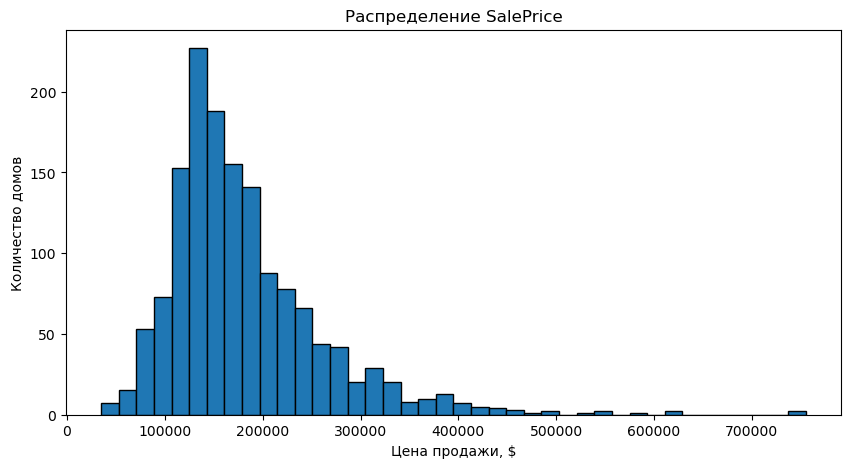

In [48]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    df[TARGET],
    bins=40,
    edgecolor="black",
)

plt.title(
    "Распределение SalePrice"
)
plt.xlabel(
    "Цена продажи, $"
)
plt.ylabel(
    "Количество домов"
)

# Отключение научного формата (Ex.: × 10⁶ )
plt.ticklabel_format(
    style="plain",
    axis="x",
)

plt.show()

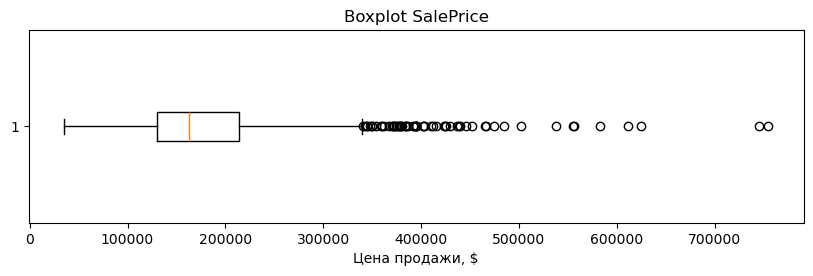

In [49]:
plt.figure(
    figsize=(10, 2.5)
)

plt.boxplot(
    df[TARGET],
    vert=False,
)

plt.title(
    "Boxplot SalePrice"
)
plt.xlabel(
    "Цена продажи, $"
)

plt.ticklabel_format(
    style="plain",
    axis="x",
)

plt.show()

In [50]:
price_extremes = pd.concat(
    [
        df.nsmallest(
            5,
            TARGET,
        ),
        df.nlargest(
            5,
            TARGET,
        ),
    ]
)

display(
    price_extremes[
        [
            "Id",
            "SalePrice",
            "Neighborhood",
            "OverallQual",
            "YearBuilt",
            "GrLivArea",
            "GarageCars",
        ]
    ]
)

,Id,SalePrice,Neighborhood,OverallQual,YearBuilt,GrLivArea,GarageCars
495,496,34900,IDOTRR,4,1920,720,0
916,917,35311,IDOTRR,2,1949,480,1
968,969,37900,OldTown,3,1910,968,0
533,534,39300,BrkSide,1,1946,334,0
30,31,40000,IDOTRR,4,1920,1317,1
691,692,755000,NoRidge,10,1994,4316,3
1182,1183,745000,NoRidge,10,1996,4476,3
1169,1170,625000,NoRidge,10,1995,3627,3
898,899,611657,NridgHt,9,2009,2364,3
803,804,582933,NridgHt,9,2008,2822,3


### Распределение таргета

Целевая переменная — `SalePrice`, цена продажи дома в долларах.

В таргете нет пропусков.

Цена находится в диапазоне от 34 900 до 755 000 долларов.

Медианная цена составляет 163 000 долларов, средняя — приблизительно
180 921 доллар. Среднее выше медианы.

Распределение имеет выраженную правую асимметрию:

- основная часть домов расположена в нижней и средней части диапазона;
- справа присутствует длинный хвост более дорогих домов;
- коэффициент асимметрии равен приблизительно 1.883.

75% объектов были проданы не дороже 214 000 долларов.

90% объектов были проданы не дороже 278 000 долларов.

Самое частое значение `SalePrice` — 140 000 долларов. Оно встречается
у 20 объектов.

## 7. Проверка проблемы MasVnrType

In [51]:
default_df = pd.read_csv(
    DATA_PATH
)

mas_vnr_reading_check = pd.Series(
    {
        (
            "Количество 'None' "
            "в исходном CSV"
        ): (
            raw_df["MasVnrType"]
            .eq("None")
            .sum()
        ),
        (
            "Количество 'NA' "
            "в исходном CSV"
        ): (
            raw_df["MasVnrType"]
            .eq("NA")
            .sum()
        ),
        (
            "Количество NaN после "
            "стандартного pd.read_csv"
        ): (
            default_df["MasVnrType"]
            .isna()
            .sum()
        ),
    },
    name="count",
)

display(
    mas_vnr_reading_check.to_frame()
)

,count
Количество 'None' в исходном CSV,864
Количество 'NA' в исходном CSV,8
Количество NaN после стандартного pd.read_csv,872


### Особенность `MasVnrType`

`MasVnrType` описывает тип каменной или кирпичной облицовки.

Значение `None` является допустимой категорией и означает, что каменная
облицовка отсутствует.

В исходном CSV:

- 864 объекта имеют значение `None`;
- 8 объектов имеют значение `NA`.

Стандартный `pd.read_csv()` объединяет эти значения и показывает
872 пропуска. Поэтому для первоначального чтения используется
`keep_default_na=False`.

## 8. Технические пропуски

In [52]:
missing_values = pd.DataFrame(
    {
        "missing_count": df.isna().sum(),
        "missing_pct": (
            df.isna().mean() * 100
        ),
    }
)

missing_values = (
    missing_values
    .query("missing_count > 0")
    .sort_values(
        "missing_count",
        ascending=False,
    )
)

missing_values["missing_pct"] = (
    missing_values["missing_pct"].round(2)
)

display(missing_values)

,missing_count,missing_pct
LotFrontage,259,17.74
GarageYrBlt,81,5.55
MasVnrArea,8,0.55
Electrical,1,0.07


In [53]:
missing_per_row = (
    df.isna()
    .sum(axis=1)
    .value_counts()
    .sort_index()
    .rename_axis(
        "missing_values_in_row"
    )
    .to_frame(
        "row_count"
    )
)

display(missing_per_row)

,row_count
missing_values_in_row,
0,1120
1,331
2,9


### Технические пропуски

После сохранения структурных категорий `NA` в датасете остаются четыре
столбца с `NaN`:

- `LotFrontage` — 259 значений;
- `GarageYrBlt` — 81 значение;
- `MasVnrArea` — 8 значений;
- `Electrical` — 1 значение.

При этом отсутствие `GarageYrBlt` совпадает с отсутствием гаража:
в датасете находится ровно 81 объект без гаража.

1120 строк не содержат ни одного `NaN`.

331 строка содержит один `NaN`.

9 строк содержат два `NaN`.

Строк с более чем двумя техническими пропусками нет.

## 9. Значения, означающие отсутствие объекта.

In [54]:
absence_tokens = {
    "Alley": (
        "NA",
        "No alley access",
    ),
    "BsmtQual": (
        "NA",
        "No basement",
    ),
    "BsmtCond": (
        "NA",
        "No basement",
    ),
    "BsmtExposure": (
        "NA",
        "No basement",
    ),
    "BsmtFinType1": (
        "NA",
        "No basement",
    ),
    "BsmtFinType2": (
        "NA",
        "No basement",
    ),
    "FireplaceQu": (
        "NA",
        "No fireplace",
    ),
    "GarageType": (
        "NA",
        "No garage",
    ),
    "GarageFinish": (
        "NA",
        "No garage",
    ),
    "GarageQual": (
        "NA",
        "No garage",
    ),
    "GarageCond": (
        "NA",
        "No garage",
    ),
    "PoolQC": (
        "NA",
        "No pool",
    ),
    "Fence": (
        "NA",
        "No fence",
    ),
    "MiscFeature": (
        "NA",
        "No miscellaneous feature",
    ),
    "MasVnrType": (
        "None",
        "No masonry veneer",
    ),
}


absence_records = []

for feature, (
    token,
    meaning,
) in absence_tokens.items():
    count = (
        raw_df[feature]
        .eq(token)
        .sum()
    )

    absence_records.append(
        {
            "feature": feature,
            "absence_token": token,
            "meaning": meaning,
            "count": count,
            "pct": count / len(raw_df) * 100,
        }
    )


absence_table = pd.DataFrame(
    absence_records
)

absence_table["pct"] = (
    absence_table["pct"].round(2)
)

absence_table = absence_table.sort_values(
    "pct",
    ascending=False,
)

display(absence_table)

,feature,absence_token,meaning,count,pct
11,PoolQC,NA,No pool,1453,99.52
13,MiscFeature,NA,No miscellaneous feature,1406,96.30
0,Alley,NA,No alley access,1369,93.77
12,Fence,NA,No fence,1179,80.75
14,MasVnrType,None,No masonry veneer,864,59.18
6,FireplaceQu,NA,No fireplace,690,47.26
7,GarageType,NA,No garage,81,5.55
8,GarageFinish,NA,No garage,81,5.55
9,GarageQual,NA,No garage,81,5.55
10,GarageCond,NA,No garage,81,5.55


### Структурное отсутствие объектов

Большая доля значений `NA` в некоторых столбцах не означает плохое
качество данных.

Эти значения описывают отсутствие соответствующей части дома:

- у 1453 объектов нет бассейна;
- у 1406 объектов нет дополнительного объекта из `MiscFeature`;
- у 1369 объектов нет доступа через аллею;
- у 1179 объектов нет забора;
- у 864 объектов нет каменной облицовки;
- у 690 объектов нет камина;
- у 81 объекта нет гаража;
- примерно у 37 объектов нет подвала.

Такие значения необходимо отличать от неизвестных или случайно
пропущенных данных.

## 10. Профиль числовых признаков

In [55]:
numeric_columns = (
    df
    .select_dtypes(
        include=np.number
    )
    .columns
)


numeric_profile = (
    df[numeric_columns]
    .describe(
        percentiles=[
            0.01,
            0.05,
            0.25,
            0.50,
            0.75,
            0.95,
            0.99,
        ]
    )
    .T
)


numeric_profile["missing_count"] = (
    df[numeric_columns]
    .isna()
    .sum()
)


numeric_profile["n_unique"] = (
    df[numeric_columns]
    .nunique(
        dropna=True
    )
)


numeric_profile["zero_count"] = (
    df[numeric_columns]
    .eq(0)
    .sum()
)


numeric_profile["zero_pct"] = (
    numeric_profile["zero_count"]
    / len(df)
    * 100
).round(2)


display(numeric_profile)

,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,missing_count,n_unique,zero_count,zero_pct
Id,1460.0,730.500000,421.610009,1.0,15.59,73.95,365.75,730.5,1095.25,1387.05,1445.41,1460.0,0,1460,0,0.00
MSSubClass,1460.0,56.897260,42.300571,20.0,20.00,20.00,20.00,50.0,70.00,160.00,190.00,190.0,0,15,0,0.00
LotFrontage,1201.0,70.049958,24.284752,21.0,21.00,34.00,59.00,69.0,80.00,107.00,141.00,313.0,259,110,0,0.00
LotArea,1460.0,10516.828082,9981.264932,1300.0,1680.00,3311.70,7553.50,9478.5,11601.50,17401.15,37567.64,215245.0,0,1073,0,0.00
OverallQual,1460.0,6.099315,1.382997,1.0,3.00,4.00,5.00,6.0,7.00,8.00,10.00,10.0,0,10,0,0.00
OverallCond,1460.0,5.575342,1.112799,1.0,3.00,4.00,5.00,5.0,6.00,8.00,9.00,9.0,0,9,0,0.00
YearBuilt,1460.0,1971.267808,30.202904,1872.0,1899.18,1916.00,1954.00,1973.0,2000.00,2007.00,2009.00,2010.0,0,112,0,0.00
YearRemodAdd,1460.0,1984.865753,20.645407,1950.0,1950.00,1950.00,1967.00,1994.0,2004.00,2007.00,2009.00,2010.0,0,61,0,0.00
MasVnrArea,1452.0,103.685262,181.066207,0.0,0.00,0.00,0.00,0.0,166.00,456.00,791.92,1600.0,8,327,861,58.97
BsmtFinSF1,1460.0,443.639726,456.098091,0.0,0.00,0.00,0.00,383.5,712.25,1274.00,1572.41,5644.0,0,637,467,31.99


### Общие диапазоны некоторых числовых признаков

- `Id`: от 1 до 1460;
- `YearBuilt`: от 1872 до 2010;
- `YearRemodAdd`: от 1950 до 2010;
- `GarageYrBlt`: от 1900 до 2010;
- `YrSold`: от 2006 до 2010;
- `MoSold`: от 1 до 12;
- `LotArea`: от 1300 до 215245 квадратных футов;
- `GrLivArea`: от 334 до 5642 квадратных футов;
- `OverallQual`: оценки от 1 до 10;
- `OverallCond`: оценки от 1 до 9, хотя шкала в описании допускает 10.

Во многих признаках площади значение `0` является допустимым и означает
отсутствие соответствующей площади, например отсутствие второго этажа,
бассейна, веранды или деревянной террасы.

## 11. Профиль категориальных признаков

In [56]:
categorical_columns = (
    df
    .select_dtypes(
        include="object"
    )
    .columns
)


categorical_records = []

for column in categorical_columns:
    value_counts = df[column].value_counts(
        dropna=False
    )

    categorical_records.append(
        {
            "feature": column,
            "n_unique": df[column].nunique(
                dropna=True
            ),
            "most_frequent_value": (
                value_counts.index[0]
            ),
            "most_frequent_count": (
                value_counts.iloc[0]
            ),
            "most_frequent_pct": (
                value_counts.iloc[0]
                / len(df)
                * 100
            ),
            "missing_count": (
                df[column]
                .isna()
                .sum()
            ),
        }
    )


categorical_profile = pd.DataFrame(
    categorical_records
)


categorical_profile["most_frequent_pct"] = (
    categorical_profile["most_frequent_pct"].round(2)
)


categorical_profile = (
    categorical_profile
    .sort_values(
        "n_unique",
        ascending=False,
    )
)


display(categorical_profile)

,feature,n_unique,most_frequent_value,most_frequent_count,most_frequent_pct,missing_count
8,Neighborhood,25,NAmes,225,15.41,0
16,Exterior2nd,16,VinylSd,504,34.52,0
15,Exterior1st,15,VinylSd,515,35.27,0
41,SaleType,9,WD,1267,86.78,0
9,Condition1,9,Norm,1260,86.30,0
14,RoofMatl,8,CompShg,1434,98.22,0
10,Condition2,8,Norm,1445,98.97,0
12,HouseStyle,8,1Story,726,49.73,0
25,BsmtFinType2,7,Unf,1256,86.03,0
31,Functional,7,Typ,1360,93.15,0


In [57]:
# Полное распределение значений любого категориального признака.

def show_category_distribution(column: str,) -> pd.DataFrame:
    result = (df[column].value_counts(dropna=False)
        .rename("count")
        .to_frame()
    )

    result["pct"] = (result["count"] / len(df) * 100).round(2)

    return result


show_category_distribution("Neighborhood")

,count,pct
Neighborhood,,
NAmes,225,15.41
CollgCr,150,10.27
OldTown,113,7.74
Edwards,100,6.85
Somerst,86,5.89
Gilbert,79,5.41
NridgHt,77,5.27
Sawyer,74,5.07
NWAmes,73,5.00


In [58]:
# Таблица из пяти самых частых значений
# каждого категориального признака.

top_category_values = []

for column in categorical_columns:
    counts = (df[column].value_counts(dropna=False).head(5))

    for value, count in counts.items():
        top_category_values.append(
            {
                "feature": column,
                "value": value,
                "count": count,
                "pct": round(
                    count / len(df) * 100,
                    2,
                ),
            }
        )


top_category_values = pd.DataFrame(
    top_category_values
)

display(top_category_values)

,feature,value,count,pct
0,MSZoning,RL,1151,78.84
1,MSZoning,RM,218,14.93
2,MSZoning,FV,65,4.45
3,MSZoning,RH,16,1.10
4,MSZoning,C (all),10,0.68
...,...,...,...,...
189,SaleCondition,Normal,1198,82.05
190,SaleCondition,Partial,125,8.56
191,SaleCondition,Abnorml,101,6.92
192,SaleCondition,Family,20,1.37


### Кардинальность категориальных признаков

Наибольшее количество категорий имеют:

- `Neighborhood` — 25 категорий;
- `Exterior2nd` — 16 категорий;
- `Exterior1st` — 15 категорий;
- `Condition1` — 9 категорий;
- `SaleType` — 9 категорий;
- `HouseStyle` — 8 категорий;
- `RoofMatl` — 8 категорий;
- `Condition2` — 8 категорий.

Самый частый район — `NAmes`. Он встречается у 225 объектов,
то есть приблизительно у 15.41% домов.

## 12. Признаки с преобладанием одного значения

In [59]:
dominant_value_records = []

feature_columns = df.columns.drop(
    [
        ID_COLUMN,
        TARGET,
    ]
)

for column in feature_columns:
    value_counts = df[column].value_counts(
        dropna=False
    )

    top_value = value_counts.index[0]
    top_count = value_counts.iloc[0]
    top_pct = top_count / len(df) * 100

    if top_pct >= 90:
        dominant_value_records.append(
            {
                "feature": column,
                "dominant_value": top_value,
                "count": top_count,
                "pct": round(top_pct, 2),
                "n_unique": df[column].nunique(dropna=False
),
            }
        )

dominant_values = pd.DataFrame(
    dominant_value_records
).sort_values(
    "pct",
    ascending=False,
)

display(dominant_values)

,feature,dominant_value,count,pct,n_unique
2,Utilities,AllPub,1459,99.93,2
0,Street,Pave,1454,99.59,2
18,PoolQC,NA,1453,99.52,4
17,PoolArea,0,1453,99.52,8
4,Condition2,Norm,1445,98.97,8
15,3SsnPorch,0,1436,98.36,20
9,LowQualFinSF,0,1434,98.22,24
5,RoofMatl,CompShg,1434,98.22,8
6,Heating,GasA,1428,97.81,6
20,MiscVal,0,1408,96.44,21


- Utilities = AllPub:       1459 домов, 99.93%
- Street = Pave:            1454 домов, 99.59%
- PoolArea = 0:             1453 дома,  99.52%
- PoolQC = NA:              1453 дома,  99.52%
- Condition2 = Norm:        1445 домов, 98.97%
- RoofMatl = CompShg:       1434 дома,  98.22%
- Heating = GasA:           1428 домов, 97.81%
- MiscFeature = NA:         1406 домов, 96.30%
- KitchenAbvGr = 1:         1392 дома,  95.34%
- LandSlope = Gtl:          1382 дома,  94.66%
- CentralAir = Y:           1365 домов, 93.49%
- Functional = Typ:         1360 домов, 93.15%
- PavedDrive = Y:           1340 домов, 91.78%
- Electrical = SBrkr:       1334 дома,  91.37%
- GarageCond = TA:          1326 домов, 90.82%

### Признаки с несбалансированным распределением значений

В нескольких признаках более 90% наблюдений имеют одно и то же значение.

Наиболее выраженные примеры:

- почти все дома подключены ко всем основным коммунальным сетям;
- почти все дома имеют асфальтированный дорожный доступ;
- бассейн встречается только у 7 объектов;
- дополнительное условие расположения `Condition2` почти всегда имеет
  значение `Norm`;
- основным материалом крыши почти всегда является `CompShg`;
- основным типом отопления является `GasA`;
- у большинства домов одна кухня;
- большинство участков имеют небольшой уклон;
- у большинства домов есть центральное кондиционирование.

На этом этапе фиксируется только фактическое распределение значений,
без принятия решений об удалении или преобразовании признаков.

## 13. Проверка согласованности связанных признаков

In [60]:
consistency_check = pd.DataFrame(
    {
        "condition": [
            "No fireplace",
            "No garage: GarageType",
            "No garage: GarageCars",
            "No garage: GarageArea",
            "No garage: GarageYrBlt",
            "No basement: BsmtQual",
            "No basement: TotalBsmtSF",
            "No pool: PoolQC",
            "No pool: PoolArea",
            "No miscellaneous feature",
            "MiscVal equals zero",
        ],
        "count": [
            raw_df["FireplaceQu"].eq("NA").sum(),
            raw_df["GarageType"].eq("NA").sum(),
            df["GarageCars"].eq(0).sum(),
            df["GarageArea"].eq(0).sum(),
            df["GarageYrBlt"].isna().sum(),
            raw_df["BsmtQual"].eq("NA").sum(),
            df["TotalBsmtSF"].eq(0).sum(),
            raw_df["PoolQC"].eq("NA").sum(),
            df["PoolArea"].eq(0).sum(),
            raw_df["MiscFeature"].eq("NA").sum(),
            df["MiscVal"].eq(0).sum(),
        ],
    }
)

display(consistency_check)

,condition,count
0,No fireplace,690
1,No garage: GarageType,81
2,No garage: GarageCars,81
3,No garage: GarageArea,81
4,No garage: GarageYrBlt,81
5,No basement: BsmtQual,37
6,No basement: TotalBsmtSF,37
7,No pool: PoolQC,1453
8,No pool: PoolArea,1453
9,No miscellaneous feature,1406


### Согласованность связанных признаков

Основные связанные признаки согласованы:

- 690 объектов имеют `Fireplaces = 0`, и у тех же 690 объектов
  отсутствует качество камина;
- 81 объект не имеет гаража во всех связанных признаках;
- 37 объектов имеют нулевую площадь подвала и отсутствие подвала;
- 1453 объекта имеют нулевую площадь бассейна и отсутствие оценки
  качества бассейна.

`MiscVal` равен нулю у 1408 объектов, тогда как `MiscFeature = NA`
встречается у 1406 объектов. Это означает, что у двух объектов указана
дополнительная особенность, но её стоимость равна нулю.

## 14. Изолированные несоответствия в признаках подвала

In [61]:
basement_field_inconsistencies = raw_df.loc[
    (
        raw_df["BsmtExposure"].eq("NA")
        | raw_df["BsmtFinType2"].eq("NA")
    )
    & df["TotalBsmtSF"].gt(0),
    [
        "Id",
        "BsmtQual",
        "BsmtCond",
        "BsmtExposure",
        "BsmtFinType1",
        "BsmtFinType2",
        "BsmtFinSF1",
        "BsmtFinSF2",
        "BsmtUnfSF",
        "TotalBsmtSF",
    ],
]

display(
    basement_field_inconsistencies
)

,Id,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinType2,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF
332,333,Gd,TA,No,GLQ,NA,1124,479,1603,3206
948,949,Gd,TA,NA,Unf,Unf,0,0,936,936


### Отдельные несоответствия в данных подвала

У 37 объектов полностью отсутствует подвал.

Однако значение `NA` встречается:

- 38 раз в `BsmtExposure`;
- 38 раз в `BsmtFinType2`.

Причина разницы — две отдельные записи:

- у объекта `Id = 333` есть подвал площадью 3206 квадратных футов,
  но отсутствует `BsmtFinType2`;
- у объекта `Id = 949` есть подвал площадью 936 квадратных футов,
  но отсутствует `BsmtExposure`.

На этом этапе эти записи только фиксируются. Способ их обработки пока
не выбирается.

## 15. Проверка дубликатов и идентификатора

In [62]:
integrity_summary = pd.Series(
    {
        "Duplicated column names": (
            df.columns.duplicated().sum()
        ),
        "Full duplicated rows": (
            df.duplicated().sum()
        ),
        "Duplicated Id": (
            df[ID_COLUMN].duplicated().sum()
        ),
        "Unique Id": (
            df[ID_COLUMN].nunique()
        ),
        (
            "Duplicated rows "
            "excluding Id"
        ): (
            df.drop(
                columns=ID_COLUMN
            )
            .duplicated()
            .sum()
        ),
    },
    name="count",
)

display(
    integrity_summary.to_frame()
)

,count
Duplicated column names,0
Full duplicated rows,0
Duplicated Id,0
Unique Id,1460
Duplicated rows excluding Id,0


## 16. Период, охваченный данными

In [63]:
date_summary = pd.Series(
    {
        "Earliest YearBuilt": (
            df["YearBuilt"].min()
        ),
        "Latest YearBuilt": (
            df["YearBuilt"].max()
        ),
        "Earliest YearRemodAdd": (
            df["YearRemodAdd"].min()
        ),
        "Latest YearRemodAdd": (
            df["YearRemodAdd"].max()
        ),
        "Earliest GarageYrBlt": (
            df["GarageYrBlt"].min()
        ),
        "Latest GarageYrBlt": (
            df["GarageYrBlt"].max()
        ),
        "Earliest YrSold": (
            df["YrSold"].min()
        ),
        "Latest YrSold": (
            df["YrSold"].max()
        ),
    },
    name="year",
)

display(
    date_summary.to_frame()
)

,year
Earliest YearBuilt,1872.0
Latest YearBuilt,2010.0
Earliest YearRemodAdd,1950.0
Latest YearRemodAdd,2010.0
Earliest GarageYrBlt,1900.0
Latest GarageYrBlt,2010.0
Earliest YrSold,2006.0
Latest YrSold,2010.0


In [64]:
sales_by_year = (
    df["YrSold"]
    .value_counts()
    .sort_index()
    .rename("house_count")
    .to_frame()
)

display(sales_by_year)

,house_count
YrSold,
2006,314
2007,329
2008,304
2009,338
2010,175


In [65]:
sales_by_month = (
    df["MoSold"]
    .value_counts()
    .sort_index()
    .rename("house_count")
    .to_frame()
)

display(sales_by_month)

,house_count
MoSold,
1,58
2,52
3,106
4,141
5,204
6,253
7,234
8,122
9,63


### Временной охват данных

Дома в датасете были построены с 1872 по 2010 год.

Годы реконструкции находятся в диапазоне с 1950 по 2010 год.

Годы строительства гаражей находятся в диапазоне с 1900 по 2010 год.

Продажи происходили с 2006 по 2010 год.

В датасете присутствуют продажи во всех месяцах с января по декабрь.

За 2010 год находится меньше наблюдений, чем за остальные годы:
175 объектов против 304–338 объектов в полных предыдущих годах.

## Итоги первичного анализа

1. Датасет содержит 1460 объектов и 81 столбец.

2. В данных находится 79 признаков, идентификатор `Id` и целевая
   переменная `SalePrice`.

3. Полных дубликатов строк и повторяющихся идентификаторов нет.

4. Целевая переменная не содержит пропусков.

5. `SalePrice` находится в диапазоне от 34 900 до 755 000 долларов.

6. Медианная цена равна 163 000 долларов, средняя — приблизительно
   180 921 доллар.

7. Распределение `SalePrice` имеет выраженную правую асимметрию.
   Коэффициент асимметрии равен приблизительно 1.883.

8. В датасете находится 43 столбца типа `object`, 35 столбцов типа
   `int64` и 3 столбца типа `float64`.

9. Некоторые числовые признаки фактически не являются непрерывными
   числами. Например, `MSSubClass` содержит коды категорий домов,
   а `OverallQual` и `OverallCond` являются порядковыми оценками.

10. После контролируемой загрузки `NaN` остаются в четырёх столбцах:
    `LotFrontage`, `GarageYrBlt`, `MasVnrArea` и `Electrical`.

11. Значения `NA` в признаках гаража, подвала, бассейна, камина,
    забора и других объектов чаще всего означают физическое отсутствие
    соответствующего объекта, а не неизвестное значение.

12. Стандартная загрузка через `pd.read_csv()` ошибочно объединяет
    значения `None` и `NA` в `MasVnrType`. В исходном файле находится
    864 значения `None` и 8 значений `NA`.

13. Основные связанные признаки согласованы: отсутствие гаража,
    камина, подвала и бассейна подтверждается соответствующими
    числовыми признаками.

14. Найдены две отдельные неполные записи в характеристиках подвала:
    `Id = 333` и `Id = 949`.

15. В ряде признаков одно значение занимает более 90% наблюдений.
    Особенно это заметно для `Utilities`, `Street`, `PoolQC`,
    `Condition2`, `RoofMatl`, `Heating` и `MiscFeature`.

16. Продажи охватывают период с 2006 по 2010 год, а годы строительства
    домов — период с 1872 по 2010 год.

На первом этапе зафиксированы структура, распределения, пропуски,
особенности чтения CSV и отдельные несоответствия данных. Зависимости
между признаками и ценой, аналитические гипотезы и способы обработки
данных пока не рассматриваются.

# 2. Осмысленные выводы и гипотезы

На этом этапе:
- изучаются связи признаков с SalePrice;
- формулируются гипотезы;
- определяются перспективные идеи Feature Engineering;
- новые признаки пока не добавляются в основной датасет.
- Корреляция и различия между группами не доказывают причинную связь.
- Все идеи позднее должны проверяться по качеству модели на кросс-валидации.

## 1. Распределение целевой переменной

Проверим, насколько асимметрично распределён `SalePrice`, и сравним
исходный таргет с его логарифмом.

In [66]:
target_distribution = pd.DataFrame(
    {
        "target_version": [
            "SalePrice",
            "log1p(SalePrice)",
        ],
        "skewness": [
            df["SalePrice"].skew(),
            np.log1p(
                df["SalePrice"]
            ).skew(),
        ],
    }
)

display(
    target_distribution.round(3)
)

,target_version,skewness
0,SalePrice,1.883
1,log1p(SalePrice),0.121


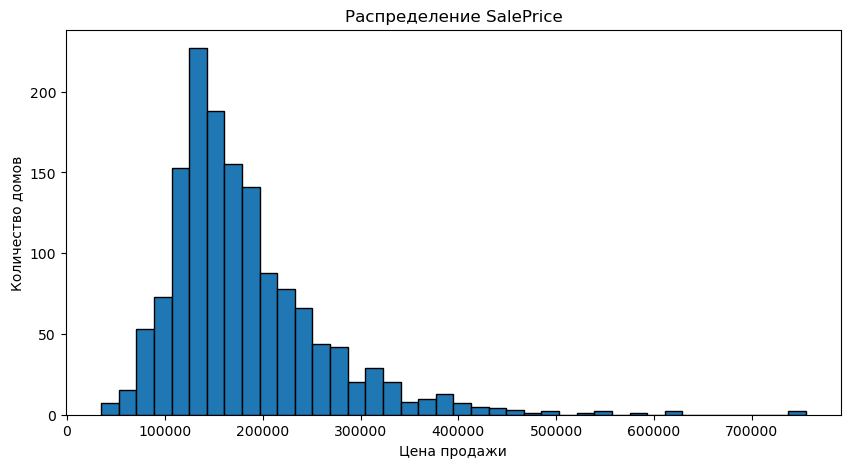

In [67]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    df["SalePrice"],
    bins=40,
    edgecolor="black",
)

plt.title(
    "Распределение SalePrice"
)
plt.xlabel(
    "Цена продажи"
)
plt.ylabel(
    "Количество домов"
)

plt.ticklabel_format(
    style="plain",
    axis="x",
)

plt.show()

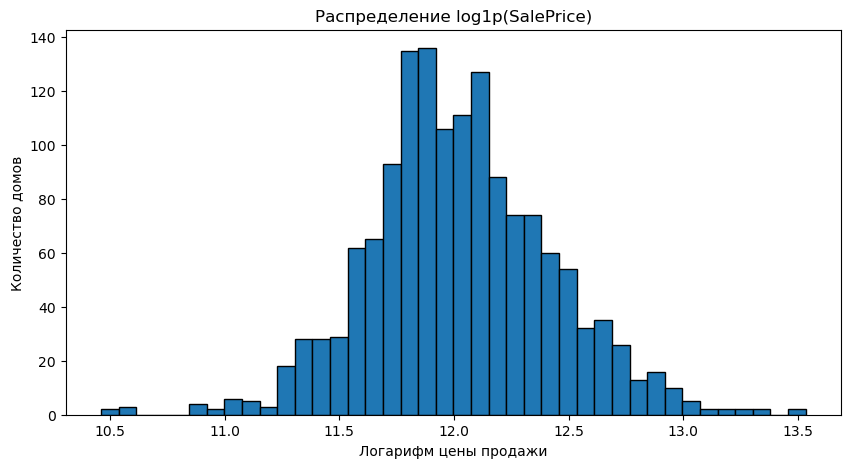

In [68]:
plt.figure(
    figsize=(10, 5)
)

plt.hist(
    np.log1p(
        df["SalePrice"]
    ),
    bins=40,
    edgecolor="black",
)

plt.title(
    "Распределение log1p(SalePrice)"
)
plt.xlabel(
    "Логарифм цены продажи"
)
plt.ylabel(
    "Количество домов"
)

plt.show()

### Вывод

Исходное распределение `SalePrice` имеет длинный правый хвост.

Небольшое количество дорогих домов находится далеко от основной части
наблюдений. Поэтому ошибки модели на таких объектах могут иметь большой
абсолютный размер.

После применения `log1p` коэффициент асимметрии уменьшается с 1.883
до 0.121.

### Гипотеза

Обучение модели на `log1p(SalePrice)` может:

- уменьшить влияние наиболее дорогих объектов;
- сделать распределение таргета более симметричным;
- сделать относительные ошибки более равномерными.

Это преобразование таргета, а не создание нового входного признака.

## 2. Основные числовые признаки

Сначала выберем числовые признаки с наиболее сильной линейной связью
с `SalePrice`, а затем посмотрим корреляции не только с таргетом,
но и между самими признаками.

In [70]:
numeric_correlations = (
    df.select_dtypes(
        include=np.number
    )
    .corr()["SalePrice"]
    .drop(
        [
            "SalePrice",
            "Id",
        ]
    )
)


top_numeric_features = (
    numeric_correlations
    .abs()
    .sort_values(
        ascending=False
    )
    .head(10)
    .index
    .tolist()
)


correlation_columns = (
    top_numeric_features
    + ["SalePrice"]
)


correlation_matrix = (
    df[correlation_columns]
    .corr()
)


display(
    correlation_matrix.round(2)
)

,OverallQual,GrLivArea,GarageCars,GarageArea,TotalBsmtSF,1stFlrSF,FullBath,TotRmsAbvGrd,YearBuilt,YearRemodAdd,SalePrice
OverallQual,1.00,0.59,0.60,0.56,0.54,0.48,0.55,0.43,0.57,0.55,0.79
GrLivArea,0.59,1.00,0.47,0.47,0.45,0.57,0.63,0.83,0.20,0.29,0.71
GarageCars,0.60,0.47,1.00,0.88,0.43,0.44,0.47,0.36,0.54,0.42,0.64
GarageArea,0.56,0.47,0.88,1.00,0.49,0.49,0.41,0.34,0.48,0.37,0.62
TotalBsmtSF,0.54,0.45,0.43,0.49,1.00,0.82,0.32,0.29,0.39,0.29,0.61
1stFlrSF,0.48,0.57,0.44,0.49,0.82,1.00,0.38,0.41,0.28,0.24,0.61
FullBath,0.55,0.63,0.47,0.41,0.32,0.38,1.00,0.55,0.47,0.44,0.56
TotRmsAbvGrd,0.43,0.83,0.36,0.34,0.29,0.41,0.55,1.00,0.10,0.19,0.53
YearBuilt,0.57,0.20,0.54,0.48,0.39,0.28,0.47,0.10,1.00,0.59,0.52
YearRemodAdd,0.55,0.29,0.42,0.37,0.29,0.24,0.44,0.19,0.59,1.00,0.51


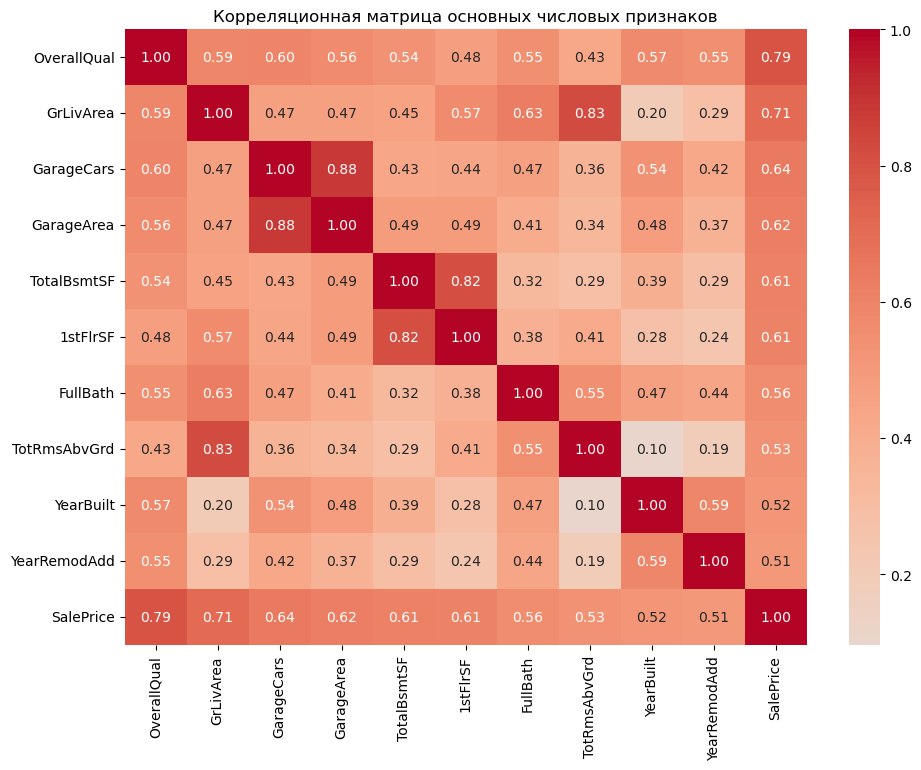

In [71]:
plt.figure(
    figsize=(11, 8)
)

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
)

plt.title(
    "Корреляционная матрица основных числовых признаков"
)

plt.show()

### Вывод

Наиболее сильная положительная линейная связь с `SalePrice`
наблюдается у:

- `OverallQual`;
- `GrLivArea`;
- `GarageCars`;
- `GarageArea`;
- `TotalBsmtSF`;
- `1stFlrSF`;
- `FullBath`;
- `TotRmsAbvGrd`;
- `YearBuilt`;
- `YearRemodAdd`.

Цена формируется сочетанием нескольких групп характеристик:

1. Качество.
2. Размер.
3. Возраст.
4. Оснащённость.
5. Местоположение.

Heatmap также показывает сильные связи между самими признаками.

Например:

- `GarageCars` и `GarageArea` описывают размер гаража;
- `GrLivArea` и `TotRmsAbvGrd` связаны через размер дома;
- `YearBuilt` и `YearRemodAdd` содержат связанную информацию
  о возрасте объекта;
- `TotalBsmtSF` и `1stFlrSF` связаны с общим размером дома.

Корреляция показывает только линейную связь. Низкая корреляция не означает,
что признак бесполезен: его влияние может быть нелинейным или зависеть
от других признаков.

### Вывод для дальнейшего анализа

В датасете присутствуют группы признаков, описывающие близкие
характеристики объекта.

Это важно учитывать при Feature Engineering, поскольку создание
дополнительных похожих признаков может привести к ещё большему
дублированию информации.

## 3. Общее качество дома

`OverallQual` — общая оценка качества материалов и отделки дома
по шкале от 1 до 10.

In [75]:
quality_summary = (
    df.groupby(
        "OverallQual"
    )["SalePrice"]
    .agg(
        house_count="size",
        median_price="median",
        mean_price="mean",
    )
    .round()
)

display(quality_summary)

,house_count,median_price,mean_price
OverallQual,,,
1,2,50150.0,50150.0
2,3,60000.0,51770.0
3,20,86250.0,87474.0
4,116,108000.0,108421.0
5,397,133000.0,133523.0
6,374,160000.0,161603.0
7,319,200141.0,207716.0
8,168,269750.0,274736.0
9,43,345000.0,367513.0


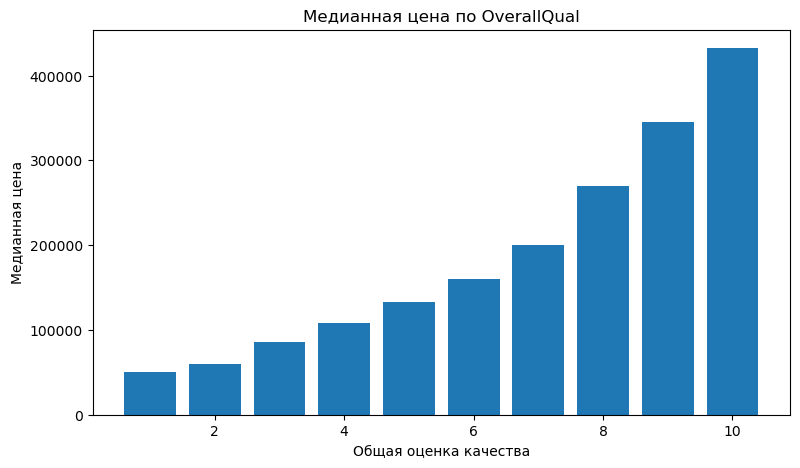

In [76]:
plt.figure(
    figsize=(9, 5)
)

plt.bar(
    quality_summary.index,
    quality_summary[
        "median_price"
    ],
)

plt.title(
    "Медианная цена по OverallQual"
)
plt.xlabel(
    "Общая оценка качества"
)
plt.ylabel(
    "Медианная цена"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
)

plt.show()

### Вывод

Медианная цена почти последовательно увеличивается вместе с
`OverallQual`.

`OverallQual` является одним из главных признаков датасета.

### Гипотеза

Влияние площади на цену зависит от качества.

Одинаковая дополнительная площадь может иметь разную стоимость
в доме низкого и высокого качества.

### Идеи Feature Engineering

- `OverallQual × GrLivArea`;
- качество × общая площадь;
- качество × возраст;
- качество × район;
- объединённый показатель площади и качества.

Такие взаимодействия особенно перспективны для линейных моделей.
Деревья решений могут частично находить их самостоятельно.

## 4. Жилая площадь и выбросы

Проверим связь между жилой площадью над землёй `GrLivArea`
и ценой продажи.

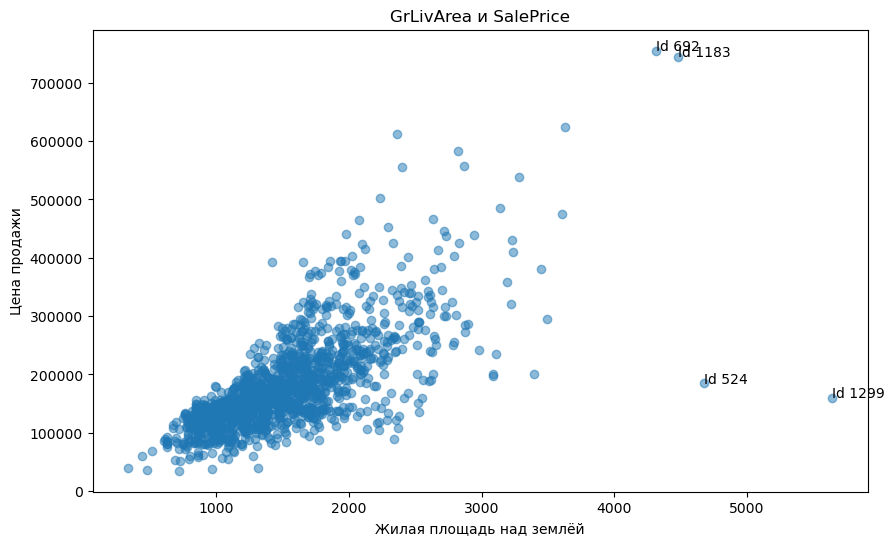

In [ ]:
plt.figure(
    figsize=(10, 6)
)

plt.scatter(
    df["GrLivArea"],
    df["SalePrice"],
    alpha=0.5,
)

large_houses = df.loc[
    df["GrLivArea"] > 4000
]

for _, row in large_houses.iterrows():
    plt.annotate(
        f'Id {row["Id"]}',
        (
            row["GrLivArea"], # Координата x
            row["SalePrice"], # Координата y
        ),
    )

plt.title(
    "GrLivArea и SalePrice"
)
plt.xlabel(
    "Жилая площадь над землёй"
)
plt.ylabel(
    "Цена продажи"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
)

plt.show()

In [78]:
large_house_table = (
    df.loc[
        df["GrLivArea"] > 4000,
        [
            "Id",
            "GrLivArea",
            "OverallQual",
            "Neighborhood",
            "SaleCondition",
            "SalePrice",
        ],
    ]
    .sort_values(
        "GrLivArea"
    )
)

display(large_house_table)

,Id,GrLivArea,OverallQual,Neighborhood,SaleCondition,SalePrice
691,692,4316,10,NoRidge,Normal,755000
1182,1183,4476,10,NoRidge,Abnorml,745000
523,524,4676,10,Edwards,Partial,184750
1298,1299,5642,10,Edwards,Partial,160000


### Вывод

В целом цена увеличивается вместе с `GrLivArea`.

Объекты `Id = 524` и `Id = 1299` заметно отклоняются от общей
зависимости: они имеют очень большую площадь и максимальное качество,
но сравнительно низкую цену.

### Гипотеза

Эти наблюдения могут сильно влиять на модели, чувствительные к большим
ошибкам.

Необычное наблюдение не обязательно является ошибкой. Причиной могут быть:

- особые условия продажи;
- особенности района;
- повреждения дома;
- нестандартный объект;
- реальная редкая ситуация.

Удалять такие объекты автоматически нельзя. Необходимо сравнить
результаты модели с ними и без них.

## 5. Состав площадей дома

Проверим, какие итоговые площади уже являются суммами других признаков.

In [ ]:
area_consistency = pd.Series(
    {
        "GrLivArea components": (
            df["GrLivArea"]
            == (
                df["1stFlrSF"]
                + df["2ndFlrSF"]
                + df["LowQualFinSF"]
            )
        ).all(),
        "TotalBsmtSF components": (
            df["TotalBsmtSF"]
            == (
                df["BsmtFinSF1"]
                + df["BsmtFinSF2"]
                + df["BsmtUnfSF"]
            )
        ).all(),
    },
    name="all_rows_equal",
)

display(
    area_consistency.to_frame()
)

,all_rows_equal
GrLivArea components,True
TotalBsmtSF components,True


### Во всех строках выполняются равенства:

`GrLivArea = 1stFlrSF + 2ndFlrSF + LowQualFinSF`

`TotalBsmtSF = BsmtFinSF1 + BsmtFinSF2 + BsmtUnfSF`

Часть признаков уже является готовыми суммами.

Не следует создавать признаки, которые полностью повторяют существующие
столбцы.

### идеи Feature Engineering

- жилая площадь вместе с подвалом;
- общая законченная площадь;
- доля законченного подвала;
- площадь на одну комнату;
- доля подвала в общей площади;
- общая площадь террас и веранд.

## 6. Возраст дома и давность реконструкции

Календарный год менее понятен для модели, чем количество лет
на момент продажи.

Создадим временные признаки только для анализа. Основной `df`
не изменяется.

In [81]:
age_analysis = df.assign(
    HouseAge=(
        df["YrSold"]
        - df["YearBuilt"]
    ),
    YearsSinceRemodel=(
        df["YrSold"]
        - df["YearRemodAdd"]
    ),
)

In [ ]:
age_bins = [
    -1,
    5,
    15,
    30,
    50,
    np.inf,
]

age_labels = [
    "0–5",
    "6–15",
    "16–30",
    "31–50",
    "51+",
]

house_age_summary = (
    age_analysis
    .assign(
        AgeGroup=pd.cut(
            age_analysis[
                "HouseAge"
            ],
            bins=age_bins,
            labels=age_labels,
        )
    )
    .groupby(
        "AgeGroup",
        observed=False,
    )["SalePrice"]
    .agg(
        house_count="size",
        median_price="median",
    )
    .round()
)

remodel_age_summary = (
    age_analysis
    .assign(
        AgeGroup=pd.cut(
            age_analysis[
                "YearsSinceRemodel"
            ],
            bins=age_bins,
            labels=age_labels,
        )
    )
    .groupby(
        "AgeGroup",
        observed=False,
    )["SalePrice"]
    .agg(
        house_count="size",
        median_price="median",
    )
    .round()
)

display(house_age_summary)
display(remodel_age_summary)

,house_count,median_price
AgeGroup,,
0–5,310,225500.0
6–15,211,213500.0
16–30,121,179000.0
31–50,379,145000.0
51+,439,127000.0


,house_count,median_price
AgeGroup,,
0–5,425,205950.0
6–15,329,188000.0
16–30,156,168500.0
31–50,305,140000.0
51+,244,118500.0


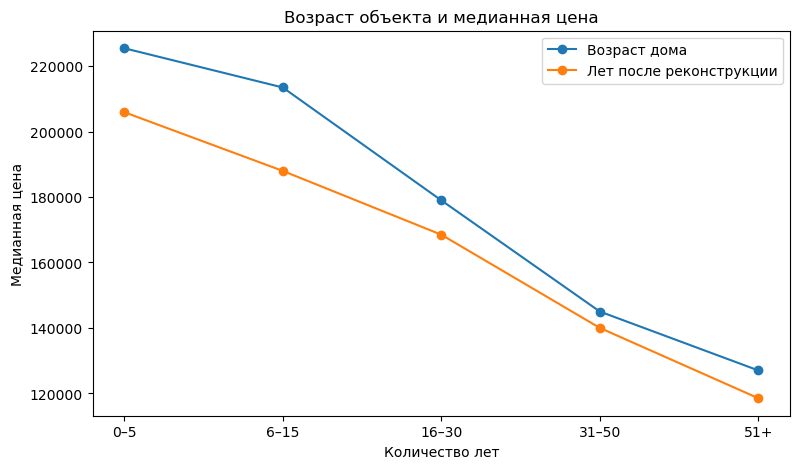

In [83]:
age_price_comparison = pd.DataFrame(
    {
        "HouseAge": (
            house_age_summary[
                "median_price"
            ]
        ),
        "YearsSinceRemodel": (
            remodel_age_summary[
                "median_price"
            ]
        ),
    }
)

plt.figure(
    figsize=(9, 5)
)

plt.plot(
    age_price_comparison.index,
    age_price_comparison[
        "HouseAge"
    ],
    marker="o",
    label="Возраст дома",
)

plt.plot(
    age_price_comparison.index,
    age_price_comparison[
        "YearsSinceRemodel"
    ],
    marker="o",
    label="Лет после реконструкции",
)

plt.title(
    "Возраст объекта и медианная цена"
)
plt.xlabel(
    "Количество лет"
)
plt.ylabel(
    "Медианная цена"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
)

plt.legend()
plt.show()

### Вывод

Медианная цена уменьшается с увеличением:

- возраста дома;
- количества лет после реконструкции.

Недавно построенные и недавно обновлённые дома в среднем стоят дороже.

### Идеи Feature Engineering

- возраст дома на момент продажи;
- количество лет после реконструкции;
- признак нового дома;
- признак дома, построенного в год продажи;
- признак недавней реконструкции;
- возраст дома к моменту реконструкции;
- возраст × качество;
- возраст × район.

## 7. Район

Сравним количество домов и медианную цену в разных районах.

In [ ]:
neighborhood_summary = (
    df.groupby("Neighborhood")["SalePrice"]
    .agg(
        house_count="size",
        median_price="median",
    )
    .sort_values(
        "median_price"
    )
    .round()
)

display(neighborhood_summary)

,house_count,median_price
Neighborhood,,
MeadowV,17,88000.0
IDOTRR,37,103000.0
BrDale,16,106000.0
OldTown,113,119000.0
Edwards,100,121750.0
BrkSide,58,124300.0
Sawyer,74,135000.0
Blueste,2,137500.0
SWISU,25,139500.0


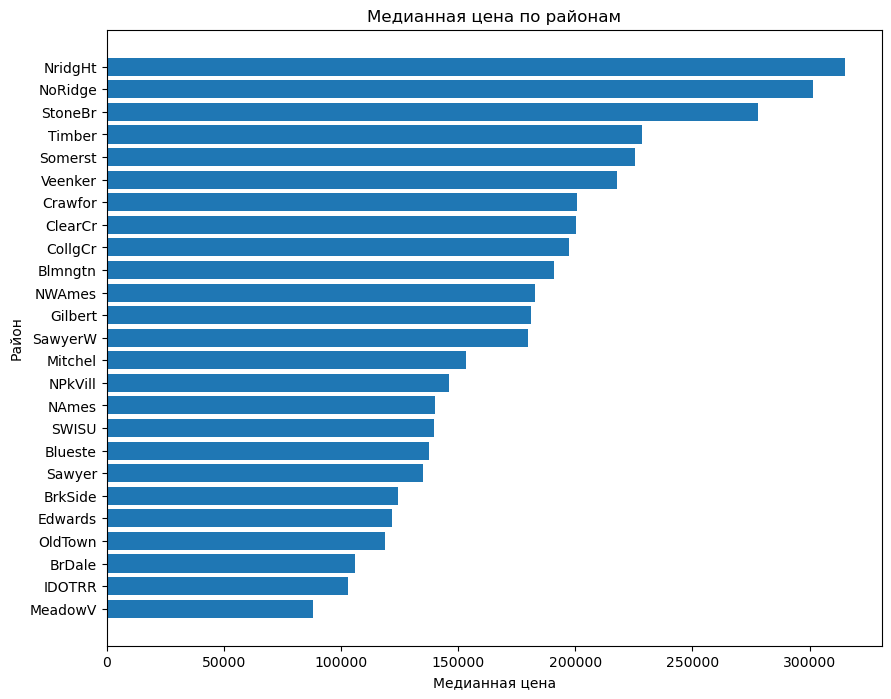

In [85]:
plt.figure(
    figsize=(10, 8)
)

plt.barh(
    neighborhood_summary.index,
    neighborhood_summary[
        "median_price"
    ],
)

plt.title(
    "Медианная цена по районам"
)
plt.xlabel(
    "Медианная цена"
)
plt.ylabel(
    "Район"
)

plt.ticklabel_format(
    style="plain",
    axis="x",
)

plt.show()

### Вывод

Медианная цена значительно различается между районами.

`Neighborhood` потенциально является одним из главных категориальных
признаков.

Однако район также связан с:

- возрастом домов;
- качеством;
- площадью;
- типом застройки;
- размером участка.

Поэтому различия нельзя считать чистым эффектом местоположения.

### Идеи Feature Engineering

- район × площадь;
- район × качество;
- район × возраст;
- относительная площадь дома внутри района;
- относительный возраст дома внутри района.

Признаки, использующие `SalePrice`, например среднюю цену района,
необходимо рассчитывать только внутри кросс-валидации. Иначе возникнет
утечка целевой переменной.

## 8. Порядковые признаки качества

У нескольких категориальных признаков существует естественный порядок:

`Po < Fa < TA < Gd < Ex`

Рассмотрим это на примере качества кухни.

In [ ]:
kitchen_quality_order = [
    "Fa",
    "TA",
    "Gd",
    "Ex",
]

kitchen_quality_summary = (
    df.groupby(
        "KitchenQual"
    )["SalePrice"]
    .agg(
        house_count="size",
        median_price="median",
    )
    .reindex( # Дай мне строки с такими индексами именно в таком порядке.
        kitchen_quality_order
    )
    .round()
)

display(
    kitchen_quality_summary
)

,house_count,median_price
KitchenQual,,
Fa,39,115000.0
TA,735,137000.0
Gd,586,201400.0
Ex,100,316750.0


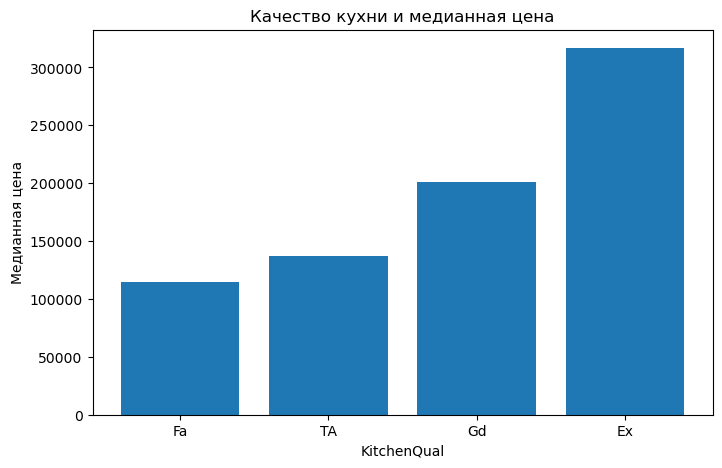

In [ ]:
plt.figure(
    figsize=(8, 5)
)

plt.bar(
    kitchen_quality_summary.index,
    kitchen_quality_summary["median_price"]
)

plt.title("Качество кухни и медианная цена")
plt.xlabel("KitchenQual")
plt.ylabel("Медианная цена")

plt.ticklabel_format(
    style="plain",
    axis="y",
)

plt.show()

### Вывод

Категории качества нельзя рассматривать только как независимые названия.
Между ними существует содержательный порядок.

Так устроены:

- `ExterQual`;
- `ExterCond`;
- `BsmtQual`;
- `BsmtCond`;
- `HeatingQC`;
- `KitchenQual`;
- `FireplaceQu`;
- `GarageQual`;
- `GarageCond`;
- `PoolQC`.

### Идеи Feature Engineering

- порядковое кодирование;
- суммарная оценка качества;
- количество элементов с оценкой `Ex`;
- количество элементов с низкой оценкой;
- минимальное качество среди основных частей дома;
- качество части дома × её площадь.

Отсутствие объекта следует отделять от оценки `Po`.

Например, отсутствие камина и камин плохого качества — разные ситуации.

## 9. Наличие основных частей дома

Сравним медианную цену объектов с гаражом, подвалом, камином
и вторым этажом.

In [ ]:
presence_conditions = {
    "Garage": (
        df["GarageArea"] > 0
    ),
    "Basement": (
        df["TotalBsmtSF"] > 0
    ),
    "Fireplace": (
        df["Fireplaces"] > 0
    ),
    "SecondFloor": (
        df["2ndFlrSF"] > 0
    ),
}

presence_records = []

for feature, condition in presence_conditions.items():
    for status, mask in {
        "No": ~condition,
        "Yes": condition,
    }.items():
        presence_records.append(
            {
                "feature": feature,
                "present": status,
                "house_count": (
                    mask.sum()
                ),
                "median_price": (
                    df.loc[
                        mask,
                        "SalePrice",
                    ]
                    .median()
                ),
            }
        )

presence_summary = pd.DataFrame(
    presence_records
)

display(presence_summary)

,feature,present,house_count,median_price
0,Garage,No,81,100000.0
1,Garage,Yes,1379,167500.0
2,Basement,No,37,101800.0
3,Basement,Yes,1423,165000.0
4,Fireplace,No,690,135000.0
5,Fireplace,Yes,770,191000.0
6,SecondFloor,No,829,150000.0
7,SecondFloor,Yes,631,177000.0


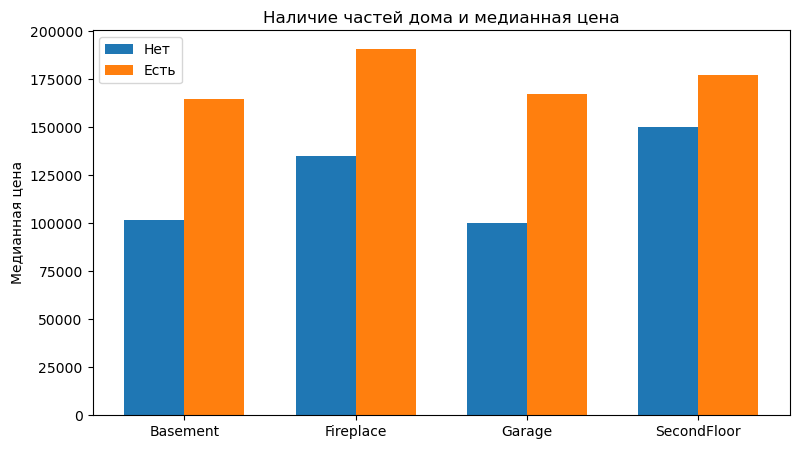

In [ ]:
presence_plot = (
    presence_summary
    .pivot(
        index="feature",
        columns="present",
        values="median_price",
    )
)

x = np.arange(len(presence_plot))

width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    presence_plot["No"],
    width,
    label="Нет",
)

plt.bar(
    x + width / 2,
    presence_plot["Yes"],
    width,
    label="Есть",
)

plt.xticks(
    x,
    presence_plot.index,
)

plt.title(
    "Наличие частей дома и медианная цена"
)
plt.ylabel(
    "Медианная цена"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
)

plt.legend()
plt.show()

### Вывод

Наличие гаража, подвала, камина и второго этажа связано с более высокой
медианной ценой.

Это не доказывает самостоятельное влияние этих объектов. Дома с гаражом
могут одновременно быть новее, больше и качественнее.

### Идеи Feature Engineering

- `HasGarage`;
- `HasBasement`;
- `HasFireplace`;
- `HasSecondFloor`;
- `HasPool`;
- `HasWoodDeck`;
- `HasPorch`;
- `HasMasonryVeneer`;
- количество дополнительных удобств.

Модель должна различать:

1. Наличие объекта.
2. Его размер.
3. Его качество.
4. Его состояние.

## 10. Общее количество ванных комнат

Ванные комнаты разделены на четыре признака:

- `FullBath`;
- `HalfBath`;
- `BsmtFullBath`;
- `BsmtHalfBath`.

Покупателю может быть важнее общее количество ванных, чем каждый
из этих признаков отдельно.

In [90]:
bathroom_analysis = df.assign(
    TotalBathrooms=(
        df["FullBath"]
        + 0.5 * df["HalfBath"]
        + df["BsmtFullBath"]
        + 0.5 * df["BsmtHalfBath"]
    )
)

bathroom_summary = (
    bathroom_analysis
    .groupby(
        "TotalBathrooms"
    )["SalePrice"]
    .agg(
        house_count="size",
        median_price="median",
    )
    .round()
)

display(bathroom_summary)

,house_count,median_price
TotalBathrooms,,
1.0,228,112250.0
1.5,129,142500.0
2.0,456,145000.0
2.5,295,184000.0
3.0,186,213750.0
3.5,144,247000.0
4.0,13,299800.0
4.5,7,250000.0
5.0,1,145900.0


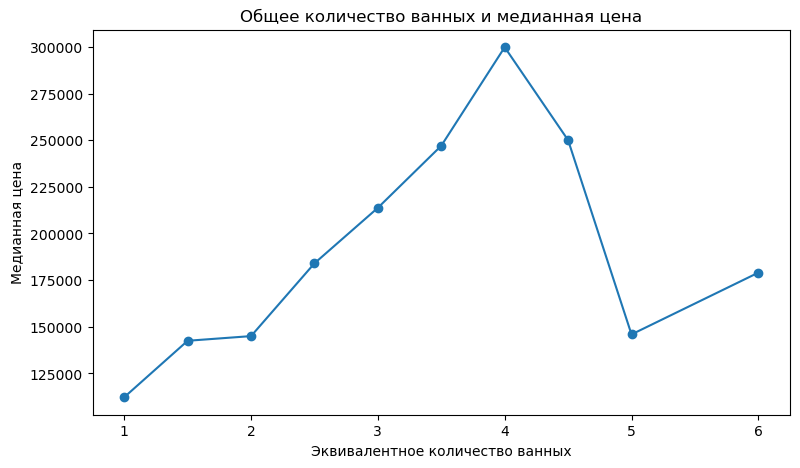

In [91]:
plt.figure(
    figsize=(9, 5)
)

plt.plot(
    bathroom_summary.index,
    bathroom_summary[
        "median_price"
    ],
    marker="o",
)

plt.title(
    "Общее количество ванных и медианная цена"
)
plt.xlabel(
    "Эквивалентное количество ванных"
)
plt.ylabel(
    "Медианная цена"
)

plt.ticklabel_format(
    style="plain",
    axis="y",
)

plt.show()

### Гипотеза

Объединённое количество ванных может быть информативнее четырёх
отдельных столбцов.

При расчёте:

- полная ванная получает вес `1`;
- половинная ванная получает вес `0.5`.

### Дополнительные идеи

- количество ванных на спальню;
- количество ванных относительно жилой площади;
- наличие ванной в подвале.

## 11. Дублирование информации

Некоторые признаки описывают похожие характеристики.

In [ ]:
related_feature_pairs = [
    (
        "GarageCars",
        "GarageArea",
    ),
    (
        "YearBuilt",
        "GarageYrBlt",
    ),
    (
        "GrLivArea",
        "TotRmsAbvGrd",
    ),
    (
        "1stFlrSF",
        "TotalBsmtSF",
    ),
]

related_features_summary = pd.DataFrame(
    [
        {
            "feature_1": feature_1,
            "feature_2": feature_2,
            "correlation": (df[feature_1].corr(df[feature_2])
            ),
        }
        for feature_1, feature_2 in related_feature_pairs
    ]
)

display(related_features_summary.round(3))

,feature_1,feature_2,correlation
0,GarageCars,GarageArea,0.882
1,YearBuilt,GarageYrBlt,0.826
2,GrLivArea,TotRmsAbvGrd,0.825
3,1stFlrSF,TotalBsmtSF,0.820


### Вывод

Некоторые признаки содержат похожую информацию:

- площадь гаража и количество машиномест;
- жилая площадь и количество комнат;
- год строительства дома и гаража;
- площадь первого этажа и площадь подвала.

Для линейных моделей сильная связь между признаками может:

- делать коэффициенты нестабильными;
- усложнять интерпретацию;
- увеличивать чувствительность к выборке.

Для деревьев это менее критично, но связанные признаки могут делить
между собой feature importance.

Не следует автоматически удалять один из двух признаков. Решение должно
приниматься по результатам кросс-валидации.

## 12. Приоритетные идеи Feature Engineering

### Высокий приоритет

| Новый признак | Основание |
|---|---|
| Возраст дома | Цена уменьшается с возрастом |
| Лет после реконструкции | Недавно обновлённые дома дороже |
| Общая площадь дома | Цена связана с несколькими площадями |
| Общая законченная площадь | Законченная площадь полезнее незаконченной |
| Общее количество ванных | Ванные разделены на четыре признака |
| Наличие гаража | Отсутствие гаража является отдельной характеристикой |
| Наличие подвала | Отсутствие подвала является отдельной характеристикой |
| Наличие камина | Наличие и качество несут разную информацию |
| Порядковое качество | Категории имеют естественный порядок |
| Площадь × качество | Ценность площади может зависеть от качества |
| Общая площадь веранд | Внешние площади разделены по типам |

### Средний приоритет

| Новый признак | Основание |
|---|---|
| Площадь на комнату | Описывает просторность планировки |
| Доля законченного подвала | Описывает полезность подвала |
| Площадь гаража на машиноместо | Разделяет площадь и вместимость |
| Количество удобств | Описывает общую оснащённость |
| Район × качество | Эффект качества может зависеть от района |
| Район × площадь | Стоимость площади может зависеть от района |
| Возраст × качество | Состояние старого дома зависит от качества |

### Экспериментальные идеи

- сезон или квартал продажи;
- объединение редких категорий;
- количество высоких оценок качества;
- количество отсутствующих частей дома;
- разница между `OverallQual` и `OverallCond`;
- относительная площадь дома внутри района;
- относительный возраст дома внутри района;
- признаки, основанные на средней цене района.

Последняя группа идей требует особенно строгой проверки на
кросс-валидации и защиты от утечки таргета.

# 13. Итоги второго этапа

1. `SalePrice` имеет выраженную правую асимметрию. Логарифмирование
   делает распределение почти симметричным.

2. Главные числовые группы признаков связаны с качеством, площадью,
   гаражом, подвалом, возрастом и количеством ванных комнат.

3. `OverallQual` является одним из наиболее информативных признаков.

4. Влияние площади может зависеть от общего качества дома.

5. Объекты `Id = 524` и `Id = 1299` являются потенциально влиятельными
   наблюдениями.

6. Часть признаков площади уже является готовыми суммами других
   столбцов. Полностью дублирующие признаки создавать не нужно.

7. Возраст дома на момент продажи понятнее и содержательнее, чем
   отдельный календарный год строительства.

8. Количество лет после реконструкции может быть информативнее самого
   года реконструкции.

9. Район связан с существенными различиями в цене, но также связан
   с качеством, возрастом и размером домов.

10. Признаки качества имеют естественный порядок и могут быть
    представлены как порядковые.

11. Наличие гаража, подвала и камина следует отделять от их размера,
    качества и состояния.

12. Некоторые исходные признаки содержат похожую информацию, поэтому
    необходимо учитывать мультиколлинеарность.

13. Все новые признаки необходимо оценивать не по логичности или
    корреляции, а по устойчивому изменению качества модели
    на кросс-валидации.

# 3. План проверки гипотез Feature Engineering

На предыдущем этапе было сформулировано много возможных идей Feature
Engineering.

Проверять все идеи нецелесообразно: датасет небольшой, а количество
экспериментов быстро растёт.

Поэтому выбираются несколько гипотез, которые:

- имеют понятный физический смысл;
- непосредственно следуют из EDA;
- потенциально объединяют информацию нескольких исходных признаков;
- достаточно универсальны для разных моделей;
- можно проверить независимо друг от друга на одной схеме CV.

Каждая гипотеза будет включаться и отключаться через config.

Базовый эксперимент содержит только обязательный preprocessing.
Затем к нему по одной добавляются группы новых признаков.

## 3.1. Гипотеза №1 — возрастные признаки

Создать признаки:

- `HouseAge = YrSold - YearBuilt`;
- `YearsSinceRemodel = YrSold - YearRemodAdd`;
- `GarageAge = YrSold - GarageYrBlt`;
- `IsRemodeled = YearRemodAdd != YearBuilt`.

### Основание

На EDA `YearBuilt` и `YearRemodAdd` входят в число числовых признаков,
наиболее связанных с `SalePrice`.

При этом абсолютный календарный год имеет менее естественный смысл,
чем возраст объекта непосредственно в момент продажи.

Например, модели проще интерпретировать:

`HouseAge = 5`

чем совместно восстанавливать возраст из:

`YearBuilt = 2005` и `YrSold = 2010`.

### Почему гипотеза имеет высокий приоритет

Она:

- имеет сильное основание в данных;
- имеет понятный физический смысл;
- использует уже существующую информацию без внешних данных;
- может помочь как линейным моделям, так и моделям на деревьях.

### Проверяемая гипотеза

Возрастные признаки дадут более удобное представление временной
информации и улучшат CV относительно использования только исходных
годов.

## 3.2. Гипотеза №2 — агрегированные площади

Создать признаки, объединяющие разные типы площади.

Основной кандидат:

`TotalSF = GrLivArea + TotalBsmtSF`

Дополнительно внутри этой группы можно рассмотреть:

`TotalFinishedSF = GrLivArea + BsmtFinSF1 + BsmtFinSF2`

и суммарную площадь веранд:

`TotalPorchSF = OpenPorchSF + EnclosedPorch + 3SsnPorch + ScreenPorch + WoodDeckSF`

### Основание

С `SalePrice` заметно связаны сразу несколько площадей:

- `GrLivArea`;
- `TotalBsmtSF`;
- `1stFlrSF`;
- `BsmtFinSF1`.

При этом они описывают разные части одного объекта.

### Почему гипотеза имеет высокий приоритет

Покупатель оценивает не только отдельный этаж или подвал, а общий
размер доступного пространства.

Агрегированный признак позволяет модели получить эту информацию
напрямую.

### Проверяемая гипотеза

Общие показатели площади будут информативнее использования только
отдельных компонентов площади.

## 3.3. Гипотеза №3 — общее количество ванных комнат

Создать:

`TotalBathrooms`

где:

- полная ванная = `1`;
- половинная ванная = `0.5`.

То есть объединить:

- `FullBath`;
- `HalfBath`;
- `BsmtFullBath`;
- `BsmtHalfBath`.

### Основание

Сейчас одна характеристика дома искусственно разделена между четырьмя
столбцами.

Например, модель должна самостоятельно понять, что:

`2 FullBath + 1 HalfBath`

соответствует большей обеспеченности ванными комнатами, чем:

`1 FullBath`.

### Почему стоит проверить

Признак:

- очень простой;
- имеет очевидный физический смысл;
- почти не увеличивает размерность;
- объединяет четыре исходных признака в одну содержательную характеристику.

### Проверяемая гипотеза

Общее эквивалентное количество ванных даст дополнительную информацию
по сравнению с использованием только четырёх исходных столбцов.